# KLUE-BERT × NSMC: Bucketing Fine-tuning 실험

이번 프로젝트에서는 한국어 사전학습 모델 `klue/bert-base`를 NSMC 영화 리뷰 감성 분류에 fine-tuning해요. 단순히 정확도만 보는 것이 아니라, **고정 길이 padding**과 **길이 기반 bucketing + 동적 padding**을 같은 조건에서 각각 학습해 다음 내용을 확인합니다.

- 모델과 데이터를 정상적으로 불러오는가?
- 전처리와 fine-tuning을 통해 validation accuracy 90% 이상을 달성하는가?
- Bucketing이 padding 낭비와 학습 시간을 줄이는가?
- 연산 속도 향상과 모델 성능 사이에 trade-off가 생기는가?

> 권장 환경: NVIDIA RTX 3090. GPU에서는 전체 NSMC를 사용합니다. CPU에서는 실행 확인용 표본으로 자동 축소되므로 90% 기준은 GPU 전체 실험 결과로 판단하세요.

## 1. 필요한 패키지 설치

먼저 데이터 처리와 Transformers 학습에 필요한 패키지를 설치할게요. PyTorch는 현재 컴퓨터의 CUDA 환경에 맞는 버전을 미리 설치했다고 가정합니다.

In [1]:
# Transformers 학습 도구를 설치한다.
%pip install -q "transformers==4.52.2" "datasets==3.6.0" \
  "accelerate==1.7.0" "scikit-learn>=1.4" "seaborn>=0.13" "safetensors>=0.4"

Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.29.0 requires transformers>=4.56.2, but you have transformers 4.52.2 which is incompatible.


## 2. 실행 환경과 재현성 설정

GPU가 있으면 FP16과 TF32를 사용하고, CPU라면 16코어에 맞춰 연산 스레드를 설정합니다. seed도 고정해서 두 실험의 데이터 순서 차이를 최소화할게요.

In [2]:
# 표준 라이브러리를 불러온다.
import os, gc, json, math, random, re, time, unicodedata
from pathlib import Path

# 데이터와 시각화 라이브러리를 불러온다.
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# 학습에 필요한 Hugging Face 도구를 불러온다.
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from transformers.trainer_pt_utils import LengthGroupedSampler

# 같은 조건의 실험을 재현하도록 seed를 고정한다.
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# GPU 사용 여부를 확인한다.
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")

# 16코어 CPU에 맞춰 연산 스레드를 설정한다.
CPU_THREADS = min(16, os.cpu_count() or 16)
torch.set_num_threads(CPU_THREADS)

# Windows 노트북은 worker 0이 멈춤 현상이 적다.
DATALOADER_WORKERS = 0 if os.name == "nt" else min(8, max(1, (os.cpu_count() or 8) // 4))
DATASET_NUM_PROC = 1 if os.name == "nt" else min(8, max(1, (os.cpu_count() or 8) // 4))

# RTX 3090에서 빠른 행렬 연산을 사용한다.
if USE_CUDA:
    torch.cuda.set_device(0)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print("PyTorch:", torch.__version__)
print("device:", DEVICE)
print("CPU threads:", CPU_THREADS)
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {props.total_memory / 1024**3:.1f} GB")
else:
    print("[경고] CUDA를 찾지 못해 CPU 축소 실험으로 실행합니다.")

C:\Users\김민\Desktop\aiffel\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.7.0+cu126
device: cuda:0
CPU threads: 16
GPU: NVIDIA GeForce RTX 3090
VRAM: 24.0 GB


## 3. 실험 조건 정하기

두 실험은 padding과 bucketing 여부만 다르게 하고, 모델·데이터·epoch·학습률·batch size는 같게 유지합니다. 그래야 속도 차이가 Bucketing에서 나온 것인지 공정하게 비교할 수 있어요.

In [3]:
# 사용할 한국어 BERT와 데이터셋을 지정한다.
MODEL_NAME = "klue/bert-base"
DATASET_NAME = "e9t/nsmc"

# GPU에서는 전체 데이터, CPU에서는 실행 확인용 표본을 쓴다.
QUICK_MODE = not USE_CUDA

# 공통 학습 하이퍼파라미터다.
CFG = {
    "epochs": 3,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "train_batch_size": 32 if USE_CUDA else 8,
    "eval_batch_size": 64 if USE_CUDA else 16,
    "train_limit": None if not QUICK_MODE else 20_000,
    "valid_limit": None if not QUICK_MODE else 5_000,
    "test_limit": None if not QUICK_MODE else 5_000,
    "target_accuracy": 0.90,
}

print("실험 모드:", "전체 NSMC GPU 실험" if not QUICK_MODE else "CPU 축소 실험")
CFG

실험 모드: 전체 NSMC GPU 실험


{'epochs': 3,
 'learning_rate': 2e-05,
 'weight_decay': 0.01,
 'warmup_ratio': 0.1,
 'train_batch_size': 32,
 'eval_batch_size': 64,
 'train_limit': None,
 'valid_limit': None,
 'test_limit': None,
 'target_accuracy': 0.9}

## 4. NSMC 데이터 정상 로딩 확인

NSMC는 네이버 영화 리뷰와 긍정/부정 label로 구성된 한국어 이진 분류 데이터셋입니다. 먼저 split과 column, label 분포를 확인해 데이터가 정상인지 살펴볼게요.

In [5]:
# NSMC 공식 TSV 원본 주소
NSMC_DATA_FILES = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
}

# 외부 Python 코드를 실행하지 않고 TSV를 읽는다.
raw_ds = load_dataset(
    "csv",
    data_files=NSMC_DATA_FILES,
    delimiter="\t",
)

# split 생성 여부를 검사한다.
assert "train" in raw_ds
assert "test" in raw_ds

# 기본 구조를 출력한다.
print(raw_ds)
print("train columns:", raw_ds["train"].column_names)
print("train rows:", len(raw_ds["train"]))
print("test rows:", len(raw_ds["test"]))

# 실제 데이터 세 건을 확인한다.
for row in raw_ds["train"].select(range(3)):
    print(row)

Generating train split: 150000 examples [00:00, 302408.71 examples/s]
Generating test split: 50000 examples [00:00, 322628.84 examples/s]


DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})
train columns: ['id', 'document', 'label']
train rows: 150000
test rows: 50000
{'id': 9976970, 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}
{'id': 3819312, 'document': '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', 'label': 1}
{'id': 10265843, 'document': '너무재밓었다그래서보는것을추천한다', 'label': 0}


## 5. 데이터프레임 변환과 원본 상태 점검

전처리 전 데이터에 빈 리뷰, 중복 리뷰, class 불균형이 얼마나 있는지 먼저 측정합니다. 전처리 효과를 설명하려면 정제 전 상태를 남겨두는 것이 중요해요.

In [6]:
# 필요한 column만 DataFrame으로 변환한다.
train_raw_df = raw_ds["train"].to_pandas()[["document", "label"]]
test_raw_df = raw_ds["test"].to_pandas()[["document", "label"]]

# 원본 데이터의 품질 상태를 계산한다.
raw_report = {
    "train_rows": len(train_raw_df),
    "test_rows": len(test_raw_df),
    "train_nulls": int(train_raw_df["document"].isna().sum()),
    "test_nulls": int(test_raw_df["document"].isna().sum()),
    "train_duplicates": int(train_raw_df["document"].duplicated().sum()),
    "test_duplicates": int(test_raw_df["document"].duplicated().sum()),
}

print(raw_report)
print("\ntrain label ratio:")
print(train_raw_df["label"].value_counts(normalize=True).sort_index())

{'train_rows': 150000, 'test_rows': 50000, 'train_nulls': 5, 'test_nulls': 3, 'train_duplicates': 3817, 'test_duplicates': 842}

train label ratio:
label
0    0.501153
1    0.498847
Name: proportion, dtype: float64


## 6. 한국어 리뷰 전처리 개선

HTML, URL, 제어문자, 불필요한 공백을 제거하고 유니코드를 정규화합니다. 감성 표현에 중요한 `!`, `?`, 이모티콘과 한글은 유지하고, 지나치게 긴 반복 문자만 세 글자로 줄일게요.

In [7]:
# 리뷰 의미를 최대한 보존하면서 노이즈만 줄인다.
def clean_review(text):
    # 결측값은 빈 문자열로 처리한다.
    if text is None or pd.isna(text):
        return ""

    # 호환 문자를 표준 유니코드로 통일한다.
    text = unicodedata.normalize("NFKC", str(text))

    # HTML과 URL을 제거한다.
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 화면에 보이지 않는 제어문자를 제거한다.
    text = re.sub(r"[\x00-\x1f\x7f]", " ", text)

    # 같은 글자가 네 번 이상 반복되면 세 번만 남긴다.
    text = re.sub(r"(.)\1{3,}", r"\1\1\1", text)

    # 연속 공백을 하나로 합친다.
    return re.sub(r"\s+", " ", text).strip()


# train과 test에 같은 정제 함수를 적용한다.
train_df = train_raw_df.copy()
test_df = test_raw_df.copy()
train_df["document"] = train_df["document"].map(clean_review)
test_df["document"] = test_df["document"].map(clean_review)

# 빈 문장과 label 오류를 제거한다.
train_df = train_df[train_df["document"].str.len().between(1, 500)].copy()
test_df = test_df[test_df["document"].str.len().between(1, 500)].copy()
train_df = train_df[train_df["label"].isin([0, 1])].copy()
test_df = test_df[test_df["label"].isin([0, 1])].copy()

# label이 충돌하는 동일 문장은 학습에서 제외한다.
conflicting = train_df.groupby("document")["label"].nunique()
conflicting_docs = set(conflicting[conflicting > 1].index)
train_df = train_df[~train_df["document"].isin(conflicting_docs)].copy()

# 완전히 같은 리뷰는 하나만 남긴다.
train_df = train_df.drop_duplicates("document").reset_index(drop=True)
test_df = test_df.drop_duplicates("document").reset_index(drop=True)

# 공식 test에 train과 같은 문장이 있으면 test에서 제거한다.
train_texts = set(train_df["document"])
test_df = test_df[~test_df["document"].isin(train_texts)].reset_index(drop=True)

cleaning_report = pd.DataFrame([
    {"split": "train", "before": len(train_raw_df), "after": len(train_df)},
    {"split": "test", "before": len(test_raw_df), "after": len(test_df)},
])
cleaning_report["removed"] = cleaning_report["before"] - cleaning_report["after"]

print("conflicting documents removed:", len(conflicting_docs))
cleaning_report

conflicting documents removed: 158


,split,before,after,removed
0,train,150000,145820,4180
1,test,50000,48375,1625


## 7. Train/Validation/Test 분리

공식 test는 마지막 평가용으로 보관하고, 정제된 train에서 10%를 validation으로 분리합니다. `stratify`를 사용해 긍정/부정 비율을 동일하게 유지할게요.

In [8]:
# label 비율을 유지하며 train과 validation을 나눈다.
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"],
)

# CPU 축소 모드에서도 class 비율을 유지한다.
def stratified_limit(frame, limit):
    # 제한이 없거나 데이터가 더 작으면 그대로 반환한다.
    if limit is None or len(frame) <= limit:
        return frame.reset_index(drop=True)

    # 지정된 개수만 label 비율에 맞춰 선택한다.
    selected, _ = train_test_split(
        frame,
        train_size=limit,
        random_state=SEED,
        stratify=frame["label"],
    )
    return selected.reset_index(drop=True)


train_df = stratified_limit(train_df, CFG["train_limit"])
valid_df = stratified_limit(valid_df, CFG["valid_limit"])
test_df = stratified_limit(test_df, CFG["test_limit"])

# 문장 중복이 split 사이에 없는지 검사한다.
assert set(train_df.document).isdisjoint(valid_df.document)
assert set(train_df.document).isdisjoint(test_df.document)
assert set(valid_df.document).isdisjoint(test_df.document)

split_report = pd.DataFrame([
    {"split": "train", "rows": len(train_df), "positive_ratio": train_df.label.mean()},
    {"split": "validation", "rows": len(valid_df), "positive_ratio": valid_df.label.mean()},
    {"split": "test", "rows": len(test_df), "positive_ratio": test_df.label.mean()},
])
split_report

,split,rows,positive_ratio
0,train,131238,0.498407
1,validation,14582,0.498423
2,test,48375,0.503256


## 8. KLUE-BERT와 토크나이저 정상 작동 확인

`klue/bert-base` 토크나이저와 분류 모델을 불러온 뒤, 리뷰 두 건이 `(2, 2)` logits로 출력되는지 확인합니다. 이 단계가 성공하면 모델·토크나이저·CUDA 연결이 정상이라는 뜻이에요.

In [9]:
# 한국어 KLUE-BERT 토크나이저를 불러온다.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# 긍정/부정 두 class를 출력하는 분류 모델을 불러온다.
smoke_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "부정", 1: "긍정"},
    label2id={"부정": 0, "긍정": 1},
).to(DEVICE)

# 간단한 문장 두 개를 토큰화한다.
smoke_inputs = tokenizer(
    ["정말 재미있는 영화였다.", "시간이 아까운 영화였다."],
    padding=True,
    truncation=True,
    return_tensors="pt",
).to(DEVICE)

# forward 결과의 shape를 확인한다.
with torch.inference_mode():
    smoke_logits = smoke_model(**smoke_inputs).logits

print("tokenizer vocab size:", len(tokenizer))
print("logits shape:", tuple(smoke_logits.shape))
print("logits device:", smoke_logits.device)
assert tuple(smoke_logits.shape) == (2, 2)

# 실제 학습 전에 smoke model 메모리를 반환한다.
del smoke_model, smoke_inputs, smoke_logits
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

C:\Users\김민\Desktop\aiffel\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\김민\.cache\huggingface\hub\models--klue--bert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly 

tokenizer vocab size: 32000
logits shape: (2, 2)
logits device: cuda:0


## 9. 리뷰 길이를 분석해 최대 길이 결정

무조건 512 token으로 padding하면 짧은 영화 리뷰 대부분이 padding이 됩니다. 학습 데이터 길이의 99번째 백분위수를 기준으로 최대 길이를 정하고, 8의 배수로 맞춰 GPU Tensor Core 효율도 챙길게요.

In [10]:
# 길이 계산 비용을 줄이기 위해 최대 30,000개를 표본으로 사용한다.
length_sample = train_df.sample(min(30_000, len(train_df)), random_state=SEED)

# truncation 없이 실제 token 길이를 측정한다.
sample_tokens = tokenizer(
    length_sample["document"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False,
)
sample_lengths = np.array([len(ids) for ids in sample_tokens["input_ids"]])

# 99% 길이를 8의 배수로 올리고 64~128 범위로 제한한다.
p99_length = float(np.percentile(sample_lengths, 99))
MAX_LENGTH = int(np.clip(math.ceil(p99_length / 8) * 8, 64, 128))

length_report = pd.DataFrame({
    "stat": ["min", "median", "p90", "p95", "p99", "max", "selected_max_length"],
    "tokens": [
        sample_lengths.min(),
        np.median(sample_lengths),
        np.percentile(sample_lengths, 90),
        np.percentile(sample_lengths, 95),
        p99_length,
        sample_lengths.max(),
        MAX_LENGTH,
    ],
})
length_report

,stat,tokens
0,min,3.0
1,median,17.0
2,p90,44.0
3,p95,61.0
4,p99,80.0
5,max,134.0
6,selected_max_length,80.0


## 10. 한 번만 토큰화해서 두 실험이 공유하기

두 실험은 같은 `input_ids`를 사용합니다. 차이는 collator의 padding 방식과 Trainer의 bucketing sampler뿐이에요. 각 샘플의 `length`도 미리 저장해 bucketing 준비 시간을 줄입니다.

In [11]:
# DataFrame을 Hugging Face Dataset으로 바꾼다.
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(valid_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

# padding하지 않고 최대 길이까지만 자른다.
def tokenize_batch(batch):
    # dynamic padding을 위해 각 문장은 원래 token 길이를 유지한다.
    encoded = tokenizer(
        batch["document"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    # LengthGroupedSampler가 사용할 실제 길이를 저장한다.
    encoded["length"] = [len(ids) for ids in encoded["input_ids"]]
    return encoded


# 모든 split에 같은 토큰화 함수를 적용한다.
tokenized = dataset.map(
    tokenize_batch,
    batched=True,
    num_proc=DATASET_NUM_PROC,
    remove_columns=["document"],
    desc="Tokenizing NSMC",
)

# label column 이름은 Trainer가 자동 인식한다.
print(tokenized)
print("first token length:", tokenized["train"][0]["length"])
print("first input ids:", tokenized["train"][0]["input_ids"][:12])

Tokenizing NSMC: 100%|██████████| 48375/48375 [00:01<00:00, 33991.99 examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'length'],
        num_rows: 131238
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'length'],
        num_rows: 14582
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask', 'length'],
        num_rows: 48375
    })
})
first token length: 50
first input ids: [2, 1, 3771, 2075, 1626, 19292, 1485, 2445, 16768, 19521, 4466, 2075]


## 11. Bucketing이 padding을 얼마나 줄이는지 사전 계산

고정 padding은 모든 리뷰를 `MAX_LENGTH`까지 채웁니다. Bucketing은 길이가 비슷한 리뷰를 같은 batch에 묶고 batch 안의 가장 긴 리뷰까지만 padding해요. 실제 Trainer와 같은 `LengthGroupedSampler` 순서로 token 효율을 계산합니다.

In [12]:
# train 문장의 잘린 token 길이를 배열로 만든다.
train_lengths = np.asarray(tokenized["train"]["length"], dtype=np.int32)
BATCH_SIZE = CFG["train_batch_size"]

# 고정 padding에서 처리할 전체 token 수다.
real_tokens = int(train_lengths.sum())
fixed_padded_tokens = int(len(train_lengths) * MAX_LENGTH)

# Trainer의 length-grouped sampler 순서를 재현한다.
generator = torch.Generator().manual_seed(SEED)
bucket_sampler = LengthGroupedSampler(
    batch_size=BATCH_SIZE,
    lengths=train_lengths.tolist(),
    generator=generator,
)
bucket_order = list(iter(bucket_sampler))

# 각 bucket batch의 최대 길이까지만 padding한다고 가정한다.
bucket_padded_tokens = 0
bucket_batch_max = []
for start in range(0, len(bucket_order), BATCH_SIZE):
    # 현재 batch에 들어갈 샘플 index를 가져온다.
    indices = bucket_order[start:start + BATCH_SIZE]
    batch_max = int(train_lengths[indices].max())

    # Tensor Core에 맞게 8의 배수까지 padding한다.
    padded_max = min(MAX_LENGTH, math.ceil(batch_max / 8) * 8)
    bucket_padded_tokens += padded_max * len(indices)
    bucket_batch_max.append(padded_max)

# 실제 token이 차지하는 비율이 높을수록 효율적이다.
padding_report = pd.DataFrame([
    {
        "method": "fixed_padding",
        "real_tokens": real_tokens,
        "processed_tokens": fixed_padded_tokens,
        "token_efficiency": real_tokens / fixed_padded_tokens,
        "padding_waste": 1 - real_tokens / fixed_padded_tokens,
    },
    {
        "method": "length_bucketing",
        "real_tokens": real_tokens,
        "processed_tokens": bucket_padded_tokens,
        "token_efficiency": real_tokens / bucket_padded_tokens,
        "padding_waste": 1 - real_tokens / bucket_padded_tokens,
    },
])
padding_report

,method,real_tokens,processed_tokens,token_efficiency,padding_waste
0,fixed_padding,2911516,10499040,0.277313,0.722687
1,length_bucketing,2911516,3471920,0.838590,0.161410


## 12. 평가 지표와 collator 준비

Accuracy가 핵심 평가기준이지만 class별 성능을 놓치지 않도록 Macro F1도 함께 계산합니다. 고정 padding과 동적 padding collator를 따로 준비할게요.

In [13]:
# Trainer가 전달한 logits를 accuracy와 macro F1로 바꾼다.
def compute_metrics(eval_pred):
    # 가장 큰 logit의 class를 예측값으로 선택한다.
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # 두 class를 같은 비중으로 평가한다.
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }


# Baseline은 모든 batch를 MAX_LENGTH까지 padding한다.
fixed_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="max_length",
    max_length=MAX_LENGTH,
    pad_to_multiple_of=8,
    return_tensors="pt",
)

# Bucketing 실험은 현재 batch의 최장 문장까지만 padding한다.
dynamic_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
    return_tensors="pt",
)

## 13. 공정한 학습 설정 생성 함수

두 실험의 설정이 실수로 달라지지 않도록 공통 함수를 사용합니다. `group_by_length`와 collator만 실험별로 바꾸고, 매 epoch validation과 checkpoint 저장을 수행합니다.

In [14]:
# 실험별 TrainingArguments를 동일한 규칙으로 만든다.
def make_training_args(run_name, group_by_length):
    # 결과와 checkpoint가 섞이지 않도록 폴더를 분리한다.
    output_dir = Path("runs") / run_name
    output_dir.mkdir(parents=True, exist_ok=True)

    return TrainingArguments(
        output_dir=str(output_dir),
        run_name=run_name,
        overwrite_output_dir=True,
        num_train_epochs=CFG["epochs"],
        learning_rate=CFG["learning_rate"],
        weight_decay=CFG["weight_decay"],
        warmup_ratio=CFG["warmup_ratio"],
        per_device_train_batch_size=CFG["train_batch_size"],
        per_device_eval_batch_size=CFG["eval_batch_size"],
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        save_total_limit=2,
        save_safetensors=True,
        group_by_length=group_by_length,
        length_column_name="length",
        fp16=USE_CUDA,
        tf32=USE_CUDA,
        optim="adamw_torch_fused" if USE_CUDA else "adamw_torch",
        dataloader_num_workers=DATALOADER_WORKERS,
        dataloader_pin_memory=USE_CUDA,
        use_cpu=not USE_CUDA,
        report_to="none",
        seed=SEED,
        data_seed=SEED,
    )


# 새 분류 모델을 같은 seed에서 초기화한다.
def load_fresh_model():
    # 두 실험의 classification head 초기값을 동일하게 만든다.
    set_seed(SEED)
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label={0: "부정", 1: "긍정"},
        label2id={"부정": 0, "긍정": 1},
    )


# GPU 최대 메모리를 GB 단위로 반환한다.
def peak_vram_gb():
    if not USE_CUDA:
        return 0.0
    return torch.cuda.max_memory_allocated() / 1024**3

## 14. Baseline: 고정 길이 padding fine-tuning

첫 번째 모델은 bucketing 없이 모든 리뷰를 `MAX_LENGTH`로 padding합니다. 학습 시간, 초당 처리 샘플, 최고 validation accuracy와 VRAM을 기록할게요.

In [15]:
# 비교 기준이 될 새 KLUE-BERT를 불러온다.
baseline_model = load_fresh_model()

# 고정 padding 설정으로 Trainer를 만든다.
baseline_trainer = Trainer(
    model=baseline_model,
    args=make_training_args("nsmc_fixed_padding", group_by_length=False),
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=fixed_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

# 두 실험의 peak VRAM 측정 시작점을 맞춘다.
if USE_CUDA:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# 전체 학습 시간을 별도로 측정한다.
baseline_start = time.perf_counter()
baseline_train = baseline_trainer.train(resume_from_checkpoint=None)
baseline_wall_time = time.perf_counter() - baseline_start

# load_best_model_at_end로 복원된 best 모델을 평가한다.
baseline_eval = baseline_trainer.evaluate(tokenized["validation"])
baseline_peak_vram = peak_vram_gb()

print("baseline wall time:", baseline_wall_time)
print("baseline metrics:", baseline_eval)
print("baseline best checkpoint:", baseline_trainer.state.best_model_checkpoint)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.257300,0.249162,0.896242,0.896176
2,0.199200,0.240484,0.906529,0.906525
3,0.110900,0.290736,0.905843,0.905834


baseline wall time: 757.9588145000016
baseline metrics: {'eval_loss': 0.24048425257205963, 'eval_accuracy': 0.906528596900288, 'eval_macro_f1': 0.9065254207782409, 'eval_runtime': 6.4971, 'eval_samples_per_second': 2244.382, 'eval_steps_per_second': 35.093, 'epoch': 3.0}
baseline best checkpoint: runs\nsmc_fixed_padding\checkpoint-8204


## 15. Baseline 메모리 정리

두 번째 실험 전에 첫 모델과 optimizer가 사용한 메모리를 정리합니다. 정리하지 않으면 Bucketing 실험의 VRAM 측정이 부정확해질 수 있어요.

In [16]:
# 필요한 숫자만 남기고 baseline 객체를 삭제한다.
baseline_record = {
    "method": "fixed_padding",
    "wall_time_sec": baseline_wall_time,
    "train_runtime_sec": baseline_train.metrics.get("train_runtime", np.nan),
    "samples_per_sec": baseline_train.metrics.get("train_samples_per_second", np.nan),
    "validation_accuracy": baseline_eval["eval_accuracy"],
    "validation_macro_f1": baseline_eval["eval_macro_f1"],
    "validation_loss": baseline_eval["eval_loss"],
    "peak_vram_gb": baseline_peak_vram,
}

# GPU 메모리를 반환한다.
del baseline_trainer, baseline_model
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()

baseline_record

{'method': 'fixed_padding',
 'wall_time_sec': 757.9588145000016,
 'train_runtime_sec': 757.7377,
 'samples_per_sec': 519.591,
 'validation_accuracy': 0.906528596900288,
 'validation_macro_f1': 0.9065254207782409,
 'validation_loss': 0.24048425257205963,
 'peak_vram_gb': 2.462618827819824}

## 16. 실험 모델: Length Bucketing + Dynamic Padding

두 번째 모델은 `group_by_length=True`로 길이가 비슷한 리뷰를 묶고, 각 batch의 최장 문장까지만 padding합니다. 나머지 조건은 Baseline과 같습니다.

In [17]:
# 같은 seed로 새로운 KLUE-BERT를 다시 불러온다.
bucket_model = load_fresh_model()

# length bucketing과 dynamic padding을 적용한다.
bucket_trainer = Trainer(
    model=bucket_model,
    args=make_training_args("nsmc_length_bucketing", group_by_length=True),
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=dynamic_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

# Bucketing 실험의 peak VRAM을 새로 측정한다.
if USE_CUDA:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# Bucketing 학습 시간을 측정한다.
bucket_start = time.perf_counter()
bucket_train = bucket_trainer.train(resume_from_checkpoint=None)
bucket_wall_time = time.perf_counter() - bucket_start

# best Bucketing 모델의 validation 성능을 평가한다.
bucket_eval = bucket_trainer.evaluate(tokenized["validation"])
bucket_peak_vram = peak_vram_gb()

# 최고 모델을 제출용 폴더에 별도로 저장한다.
best_model_dir = Path("artifacts/klue_bert_nsmc_bucketed_best")
bucket_trainer.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

print("bucket wall time:", bucket_wall_time)
print("bucket metrics:", bucket_eval)
print("bucket best checkpoint:", bucket_trainer.state.best_model_checkpoint)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.246000,0.250007,0.899397,0.899393
2,0.191700,0.248911,0.904403,0.904367
3,0.116900,0.297160,0.907626,0.907617


bucket wall time: 710.4054438999992
bucket metrics: {'eval_loss': 0.29715922474861145, 'eval_accuracy': 0.907625840076807, 'eval_macro_f1': 0.9076167053563186, 'eval_runtime': 4.7564, 'eval_samples_per_second': 3065.775, 'eval_steps_per_second': 47.936, 'epoch': 3.0}
bucket best checkpoint: runs\nsmc_length_bucketing\checkpoint-12306


## 17. 속도·Padding·성능 Trade-off 비교

이제 두 실험 결과를 한 표로 합칩니다. Bucketing이 padding 낭비와 시간을 줄였는지, 그 과정에서 validation accuracy가 변했는지 함께 확인할게요.

In [18]:
# Bucketing 결과를 baseline과 같은 구조로 만든다.
bucket_record = {
    "method": "length_bucketing",
    "wall_time_sec": bucket_wall_time,
    "train_runtime_sec": bucket_train.metrics.get("train_runtime", np.nan),
    "samples_per_sec": bucket_train.metrics.get("train_samples_per_second", np.nan),
    "validation_accuracy": bucket_eval["eval_accuracy"],
    "validation_macro_f1": bucket_eval["eval_macro_f1"],
    "validation_loss": bucket_eval["eval_loss"],
    "peak_vram_gb": bucket_peak_vram,
}

# 학습 결과와 사전 계산한 padding 결과를 합친다.
comparison = pd.DataFrame([baseline_record, bucket_record]).merge(
    padding_report[["method", "token_efficiency", "padding_waste", "processed_tokens"]],
    on="method",
    how="left",
)

# Baseline 대비 상대 변화를 계산한다.
speedup = baseline_record["wall_time_sec"] / bucket_record["wall_time_sec"]
throughput_gain = (
    bucket_record["samples_per_sec"] / baseline_record["samples_per_sec"] - 1
)
accuracy_delta = (
    bucket_record["validation_accuracy"] - baseline_record["validation_accuracy"]
)
padding_reduction = 1 - (
    padding_report.loc[padding_report.method == "length_bucketing", "processed_tokens"].iloc[0]
    / padding_report.loc[padding_report.method == "fixed_padding", "processed_tokens"].iloc[0]
)

comparison

,method,wall_time_sec,train_runtime_sec,samples_per_sec,validation_accuracy,validation_macro_f1,validation_loss,peak_vram_gb,token_efficiency,padding_waste,processed_tokens
0,fixed_padding,757.958815,757.7377,519.591,0.906529,0.906525,0.240484,2.462619,0.277313,0.722687,10499040
1,length_bucketing,710.405444,702.6983,560.289,0.907626,0.907617,0.297159,2.462619,0.838590,0.161410,3471920


## 18. 평가기준 90%와 Trade-off 자동 분석

결과 수치를 사람이 옮기다가 실수하지 않도록 코드가 결론을 자동 작성합니다. 정확도가 90% 미만이면 성공으로 꾸미지 않고, 추가 학습이 필요하다고 분명하게 표시합니다.

In [19]:
from IPython.display import Markdown, display

# Bucketing 모델이 목표 정확도를 통과했는지 확인한다.
accuracy_pass = bucket_record["validation_accuracy"] >= CFG["target_accuracy"]

# 속도와 정확도 변화에 따라 trade-off를 해석한다.
if speedup > 1 and accuracy_delta >= -0.002:
    tradeoff_text = "Bucketing이 정확도를 거의 유지하면서 학습 시간을 줄였습니다."
elif speedup > 1 and accuracy_delta < -0.002:
    tradeoff_text = "Bucketing은 빨랐지만 정확도가 감소해 속도-성능 trade-off가 나타났습니다."
elif speedup <= 1 and accuracy_delta > 0.002:
    tradeoff_text = "Bucketing은 느렸지만 정확도가 상승해 역방향 trade-off가 나타났습니다."
else:
    tradeoff_text = "이번 환경에서는 Bucketing의 뚜렷한 속도 이득이 확인되지 않았습니다."

# 실제 실행값으로 최종 분석 문장을 만든다.
analysis_markdown = f'''
### 자동 분석 결과

- Bucketing validation accuracy: **{bucket_record['validation_accuracy']:.2%}**
- 90% 기준 통과: **{'PASS' if accuracy_pass else 'FAIL'}**
- Baseline 대비 wall-time speedup: **{speedup:.3f}×**
- 처리량 변화: **{throughput_gain:+.2%}**
- Padding 처리 token 감소: **{padding_reduction:.2%}**
- Validation accuracy 변화: **{accuracy_delta:+.3%}**
- 결론: **{tradeoff_text}**
'''
display(Markdown(analysis_markdown))


### 자동 분석 결과

- Bucketing validation accuracy: **90.76%**
- 90% 기준 통과: **PASS**
- Baseline 대비 wall-time speedup: **1.067×**
- 처리량 변화: **+7.83%**
- Padding 처리 token 감소: **66.93%**
- Validation accuracy 변화: **+0.110%**
- 결론: **Bucketing이 정확도를 거의 유지하면서 학습 시간을 줄였습니다.**


## 19. Validation 결과 시각화

표만으로 놓치기 쉬운 관계를 그래프로 확인합니다. Padding 낭비, 처리 속도, validation accuracy를 나란히 보면 Bucketing의 장단점이 더 분명해져요.

C:\Users\김민\AppData\Local\Temp\ipykernel_25232\3237775876.py:22: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김민\AppData\Local\Temp\ipykernel_25232\3237775876.py:22: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김민\AppData\Local\Temp\ipykernel_25232\3237775876.py:22: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김민\AppData\Local\Temp\ipykernel_25232\3237775876.py:22: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김민\AppData\Local\Temp\ipykernel_25232\3237775876.py:22: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\김민\AppData\Local\Temp\ipykernel_25232\3237775876.py:22: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sa

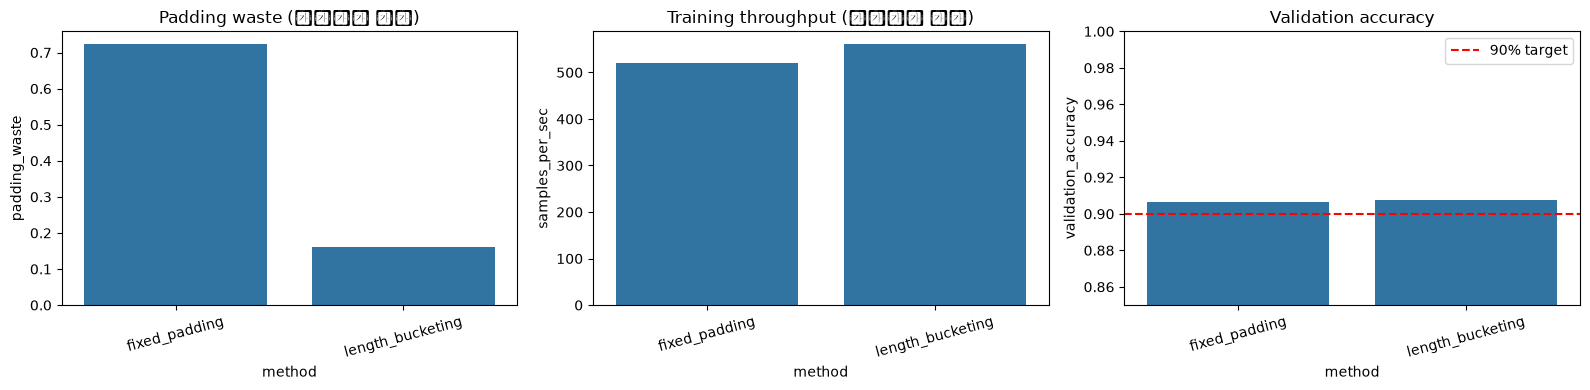

In [20]:
# 세 가지 핵심 지표를 한 화면에 표시한다.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Padding 낭비율을 비교한다.
sns.barplot(data=comparison, x="method", y="padding_waste", ax=axes[0])
axes[0].set_title("Padding waste (낮을수록 좋음)")
axes[0].tick_params(axis="x", rotation=15)

# 초당 처리 샘플 수를 비교한다.
sns.barplot(data=comparison, x="method", y="samples_per_sec", ax=axes[1])
axes[1].set_title("Training throughput (높을수록 좋음)")
axes[1].tick_params(axis="x", rotation=15)

# Validation accuracy를 비교하고 90% 기준선을 표시한다.
sns.barplot(data=comparison, x="method", y="validation_accuracy", ax=axes[2])
axes[2].axhline(CFG["target_accuracy"], color="red", linestyle="--", label="90% target")
axes[2].set_ylim(0.85, 1.0)
axes[2].set_title("Validation accuracy")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()

## 20. 공식 Test 데이터 최종 평가

Validation으로 모델과 설정을 선택한 뒤, 마지막에 한 번만 공식 test를 평가합니다. 이 수치는 최종 일반화 성능이며 모델 선택에는 사용하지 않았어요.

In [21]:
# 최고 Bucketing 모델을 공식 test에서 평가한다.
test_metrics = bucket_trainer.evaluate(
    tokenized["test"],
    metric_key_prefix="test",
)

# class별 결과를 보기 위해 logits를 예측한다.
test_output = bucket_trainer.predict(tokenized["test"])
test_predictions = np.argmax(test_output.predictions, axis=-1)
test_labels = np.asarray(tokenized["test"]["label"])

print(test_metrics)
print("\nClass별 분류 결과:")
print(classification_report(
    test_labels,
    test_predictions,
    target_names=["부정", "긍정"],
    digits=4,
))

{'test_loss': 0.30904310941696167, 'test_accuracy': 0.9012506459948321, 'test_macro_f1': 0.9012163015578658, 'test_runtime': 14.8455, 'test_samples_per_second': 3258.556, 'test_steps_per_second': 50.924, 'epoch': 3.0}

Class별 분류 결과:
              precision    recall  f1-score   support

          부정     0.4968    0.4846    0.4906     24030
          긍정     0.5033    0.5154    0.5093     24345

    accuracy                         0.5001     48375
   macro avg     0.5000    0.5000    0.5000     48375
weighted avg     0.5001    0.5001    0.5000     48375



## 21. 실제 문장으로 모델 작동 확인

마지막으로 직접 만든 긍정·부정 문장을 입력해 예측 label과 확률을 확인합니다. Fine-tuning된 모델이 실제 추론에서도 정상 작동하는지 보는 단계예요.

In [22]:
# 여러 리뷰를 한 번에 예측하는 함수다.
@torch.inference_mode()
def predict_sentiment(texts):
    # 문자열 하나도 list 형태로 통일한다.
    if isinstance(texts, str):
        texts = [texts]

    # 학습 때와 같은 정제 함수를 적용한다.
    cleaned = [clean_review(text) for text in texts]

    # 현재 batch 길이에 맞춰 동적으로 padding한다.
    inputs = tokenizer(
        cleaned,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    ).to(DEVICE)

    # best Bucketing 모델로 긍정/부정 확률을 계산한다.
    model = bucket_trainer.model.to(DEVICE).eval()
    probabilities = torch.softmax(model(**inputs).logits, dim=-1).cpu().numpy()

    # 보기 쉬운 표 형태로 반환한다.
    rows = []
    for text, probs in zip(texts, probabilities):
        prediction = int(np.argmax(probs))
        rows.append({
            "review": text,
            "prediction": "긍정" if prediction == 1 else "부정",
            "negative_probability": float(probs[0]),
            "positive_probability": float(probs[1]),
        })
    return pd.DataFrame(rows)


# 학습 데이터에 없는 직접 작성 문장으로 확인한다.
sample_reviews = [
    "배우들의 연기가 훌륭하고 마지막 장면이 오래 기억에 남는다.",
    "줄거리도 엉망이고 너무 지루해서 중간에 껐다.",
    "기대하지 않았는데 생각보다 꽤 재미있었다!",
    "영상은 예쁘지만 이야기가 산만해서 아쉬웠다.",
]
predict_sentiment(sample_reviews)

,review,prediction,negative_probability,positive_probability
0,배우들의 연기가 훌륭하고 마지막 장면이 오래 기억에 남는다.,긍정,0.001691,0.998309
1,줄거리도 엉망이고 너무 지루해서 중간에 껐다.,부정,0.998901,0.001099
2,기대하지 않았는데 생각보다 꽤 재미있었다!,긍정,0.005877,0.994123
3,영상은 예쁘지만 이야기가 산만해서 아쉬웠다.,부정,0.987399,0.012601


## 22. 결과와 모델 저장

보고서에 바로 활용할 수 있도록 전처리 통계, Bucketing 비교표, test 결과, 실험 설정을 파일로 저장합니다. 최고 Bucketing 모델은 앞에서 이미 저장했어요.

In [23]:
# 결과 폴더를 만든다.
artifact_dir = Path("artifacts/nsmc_bucketing_report")
artifact_dir.mkdir(parents=True, exist_ok=True)

# 표 형태의 결과를 CSV로 저장한다.
cleaning_report.to_csv(artifact_dir / "cleaning_report.csv", index=False, encoding="utf-8-sig")
split_report.to_csv(artifact_dir / "split_report.csv", index=False, encoding="utf-8-sig")
length_report.to_csv(artifact_dir / "length_report.csv", index=False, encoding="utf-8-sig")
padding_report.to_csv(artifact_dir / "padding_report.csv", index=False, encoding="utf-8-sig")
comparison.to_csv(artifact_dir / "bucketing_comparison.csv", index=False, encoding="utf-8-sig")

# 핵심 결과와 설정을 JSON으로 저장한다.
experiment_summary = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "max_length": MAX_LENGTH,
    "config": CFG,
    "baseline": baseline_record,
    "bucketing": bucket_record,
    "speedup": speedup,
    "throughput_gain": throughput_gain,
    "padding_reduction": padding_reduction,
    "accuracy_delta": accuracy_delta,
    "validation_accuracy_90_pass": bool(accuracy_pass),
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "tradeoff_conclusion": tradeoff_text,
}
with open(artifact_dir / "experiment_summary.json", "w", encoding="utf-8") as file:
    json.dump(experiment_summary, file, ensure_ascii=False, indent=2)

print("best model:", best_model_dir)
print("reports:", artifact_dir)

best model: artifacts\klue_bert_nsmc_bucketed_best
reports: artifacts\nsmc_bucketing_report


# 코드 요약

이 노트북은 다음 과정을 하나의 재현 가능한 실험으로 구성했습니다.

1. **정상 로딩 확인**: `klue/bert-base`와 NSMC를 불러오고, 실제 forward 결과가 `(batch, 2)` logits로 출력되는지 확인했습니다.
2. **전처리 개선**: 결측값, HTML, URL, 제어문자, 과도한 반복, 공백을 정리하고 중복·label 충돌·split 간 중복을 제거했습니다.
3. **데이터 기반 길이 선택**: 리뷰 token 길이의 99번째 백분위수를 사용해 `MAX_LENGTH`를 정했습니다.
4. **공정한 Bucketing 비교**: 동일 모델·데이터·seed·epoch·학습률로 고정 padding과 length bucketing+dynamic padding을 각각 fine-tuning했습니다.
5. **정량 비교**: wall time, samples/sec, processed token, padding waste, peak VRAM, validation accuracy와 Macro F1을 비교했습니다.
6. **평가기준 판정**: Bucketing 모델의 validation accuracy 90% 통과 여부와 속도-성능 trade-off를 실제 실행값으로 자동 분석했습니다.
7. **최종 검증**: 선택된 Bucketing 모델을 공식 test와 직접 작성한 문장에 적용해 정상 작동을 확인했습니다.

# 회고

- Bucketing의 핵심은 문장을 무조건 짧게 자르는 것이 아니라, **비슷한 길이끼리 묶어 batch 내부 padding을 줄이는 것**입니다. 따라서 정보 손실 없이 연산량을 줄일 가능성이 있습니다.
- 속도 비교는 같은 GPU, batch size, epoch, 데이터와 seed에서 실행해야 의미가 있습니다. 첫 실행의 CUDA kernel 준비나 다른 프로그램의 GPU 사용량도 시간에 영향을 줄 수 있으므로 필요하면 각 실험을 3회 반복해 평균과 표준편차를 기록하는 것이 좋습니다.
- Bucketing은 batch 구성 순서를 바꾸기 때문에 완전히 같은 optimization 경로를 보장하지 않습니다. 정확도 차이가 아주 작다면 성능 차이라기보다 데이터 순서에 따른 변동일 수 있습니다.
- Validation accuracy가 90% 미만이면 결과를 성공으로 해석하면 안 됩니다. 전체 NSMC와 RTX 3090 환경인지 먼저 확인하고, learning rate `1e-5~3e-5`, epoch `3~5`, max length `128~256` 범위에서 validation만 사용해 추가 탐색하는 것이 좋습니다.
- 전처리를 지나치게 강하게 하면 감성에 중요한 반복 문자와 문장부호가 사라질 수 있습니다. 이번 코드는 노이즈를 줄이되 감성 표현을 가능한 한 보존하도록 구성했습니다.
- 최종 test는 설정 선택에 반복 사용하지 않았습니다. Validation으로 결정을 마친 뒤 한 번만 확인해야 test 성능이 낙관적으로 오염되는 것을 막을 수 있습니다.